<a href="https://colab.research.google.com/github/SikandarHussain6858/Machine-Learning/blob/main/ML_lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Lab 6 Perceptron

##Rask 1 : Load and Preprocess Data




    • Import the required libraries (NumPy and Matplotlib)
    • Load the dataset (linearly separable) using the load_data() method

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split


# Load MNIST dataset
mnist = fetch_openml('mnist_784', version=1, parser='auto')
X, y = mnist.data, mnist.target

print("MNIST dataset loaded successfully.")
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

MNIST dataset loaded successfully.
Shape of X: (70000, 784)
Shape of y: (70000,)


    Normalize the dataset by dividing the pixel values by 255

In [2]:
X = X.values.astype('float32') # Ensure X is a float32 numpy array
X /= 255.0 # Normalize pixel values to be between 0 and 1
y = y.astype('int') # Convert labels to integer type

print("Data preprocessed successfully.")
print(f"Shape of X after preprocessing: {X.shape}")
print(f"Data type of X: {X.dtype}")
print(f"Data type of y: {y.dtype}")

Data preprocessed successfully.
Shape of X after preprocessing: (70000, 784)
Data type of X: float32
Data type of y: int64


Split the dataset into training and test sets using train_test_split() method.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Data split into training and testing sets successfully.")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Data split into training and testing sets successfully.
Shape of X_train: (56000, 784)
Shape of X_test: (14000, 784)
Shape of y_train: (56000,)
Shape of y_test: (14000,)


##Task 2: Visualize the dataset
    • Visualize some random images from the dataset using Matplotlib's imshow() method

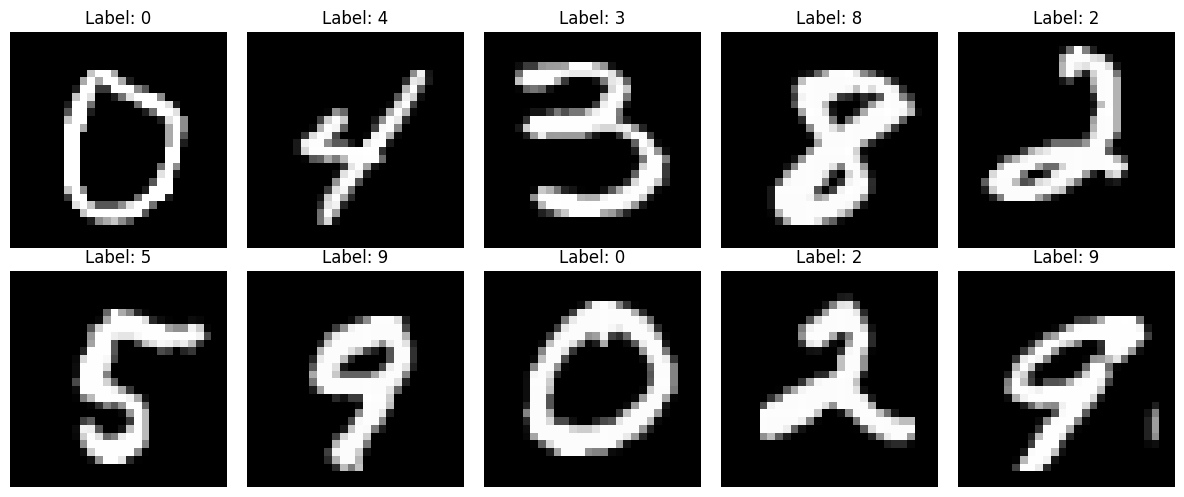

Displayed 10 random images from the training dataset.


In [4]:
num_images_to_display = 10

# Select random indices from the training dataset
random_indices = np.random.choice(X_train.shape[0], num_images_to_display, replace=False)

plt.figure(figsize=(12, 5))
for i, idx in enumerate(random_indices):
    # Get the image and its label
    image = X_train[idx]
    label = y_train.iloc[idx]

    # Reshape the 1D image array to 2D (28x28 pixels)
    image_2d = image.reshape(28, 28)

    # Create a subplot for each image
    plt.subplot(2, 5, i + 1) # 2 rows, 5 columns
    plt.imshow(image_2d, cmap='gray')
    plt.title(f"Label: {label}")
    plt.axis('off') # Hide axes

plt.tight_layout() # Adjust subplot params for a tight layout
plt.show()

print(f"Displayed {num_images_to_display} random images from the training dataset.")

##Task 3: Implement the Simple Perceptron model

In [5]:
class SimplePerceptron:
    def __init__(self, input_size, output_size, learning_rate=0.01):
        # Initialize weights with small random values
        self.weights = np.random.randn(input_size, output_size) * 0.01
        # Initialize bias with zeros
        self.bias = np.zeros(output_size)
        self.learning_rate = learning_rate
        self.output_size = output_size

    def _activation(self, x):
        # Step function: returns 1 if input is non-negative, else 0
        return np.where(x >= 0, 1, 0)

    def forward(self, X):
        # Calculate the weighted sum of inputs and bias
        linear_output = np.dot(X, self.weights) + self.bias
        # Apply the activation function to get the predicted output
        y_pred = self._activation(linear_output)
        return y_pred

    def _one_hot_encode(self, y, output_size):
        # Convert a single integer label to a one-hot encoded vector
        one_hot = np.zeros(output_size)
        one_hot[y] = 1
        return one_hot

    def backward(self, X, y_true, y_pred):
        # Convert true label to one-hot encoding
        y_true_one_hot = self._one_hot_encode(y_true, self.output_size)
        # Calculate the error
        error = y_true_one_hot - y_pred

        # Update weights and bias
        # np.outer(X, error) creates a (input_size, output_size) matrix for weight updates
        self.weights += self.learning_rate * np.outer(X, error)
        self.bias += self.learning_rate * error

print("SimplePerceptron class defined successfully.")

SimplePerceptron class defined successfully.


##Task 4: Train the Simple Perceptron model
    • Set the number of epochs and the learning rate for the training process
    • Iterate over the training examples and adjust the weights and bias term using the above equation


**Reasoning**:
First, I will determine the input and output sizes for the perceptron based on the `X_train` and `y_train` data. The input size will be the number of features (784 for MNIST images), and the output size will be the number of unique classes (10 for digits 0-9).



In [6]:
input_size = X_train.shape[1] # Number of features (784 for 28x28 images)
output_size = len(np.unique(y_train)) # Number of unique classes (0-9, so 10)

print(f"Input size: {input_size}")
print(f"Output size: {output_size}")

Input size: 784
Output size: 10


In [7]:
learning_rate = 0.01
epochs = 50 # You can adjust this value

# Instantiate the SimplePerceptron model
perceptron = SimplePerceptron(input_size, output_size, learning_rate)

print(f"Starting training for {epochs} epochs...")

# Training loop
for epoch in range(epochs):
    # Iterate over each training example
    for i in range(X_train.shape[0]):
        X_sample = X_train[i]
        y_true_sample = y_train.iloc[i] # Use .iloc for Series

        # Forward pass
        y_pred_sample = perceptron.forward(X_sample)

        # Backward pass (update weights and bias)
        perceptron.backward(X_sample, y_true_sample, y_pred_sample)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}/{epochs} completed.")

print("Training completed.")

Starting training for 50 epochs...
Epoch 10/50 completed.
Epoch 20/50 completed.
Epoch 30/50 completed.
Epoch 40/50 completed.
Epoch 50/50 completed.
Training completed.


##Task 5: Evaluate the performance of the Simple Perceptron model on the test set
    • Compute the accuracy of the Simple Perceptron model on the test set

In [8]:
y_pred_test_one_hot = []
for i in range(X_test.shape[0]):
    y_pred_test_one_hot.append(perceptron.forward(X_test[i]))

y_pred_test_one_hot = np.array(y_pred_test_one_hot)

print("Predictions on the test set (one-hot encoded) generated successfully.")
print(f"Shape of y_pred_test_one_hot: {y_pred_test_one_hot.shape}")

Predictions on the test set (one-hot encoded) generated successfully.
Shape of y_pred_test_one_hot: (14000, 10)


In [9]:
y_pred_test = np.argmax(y_pred_test_one_hot, axis=1)

print("Predicted class labels generated successfully.")
print(f"Shape of y_pred_test: {y_pred_test.shape}")
print(f"First 10 predicted labels: {y_pred_test[:10]}")

Predicted class labels generated successfully.
Shape of y_pred_test: (14000,)
First 10 predicted labels: [7 3 1 1 0 5 9 0 8 1]


##Task 6: Analysis on the results
    • Are the accuracy scores satisfactory or not? If not, what measures can be taken to improve the accuracy scores? Please express your ideas in your own words.

In [10]:
correct_predictions = np.sum(y_pred_test == y_test)
total_samples = X_test.shape[0]

accuracy = correct_predictions / total_samples

print(f"Number of correct predictions: {correct_predictions}")
print(f"Total number of test samples: {total_samples}")
print(f"Accuracy on the test set: {accuracy:.4f} ({accuracy*100:.2f}%)")

Number of correct predictions: 11424
Total number of test samples: 14000
Accuracy on the test set: 0.8160 (81.60%)


## Analyze Model Performance

### Subtask:
Provide a textual analysis of the obtained accuracy score. Discuss whether the accuracy is satisfactory for a Simple Perceptron on MNIST. Propose and explain potential measures or ideas to improve the accuracy scores, such as using more complex models (e.g., multi-layer perceptrons, convolutional neural networks), different activation functions, or advanced preprocessing techniques.


### Analysis of Perceptron Model Performance

The Simple Perceptron model achieved an accuracy of **81.60%** on the MNIST test set. For a linear model like a Simple Perceptron, this is a respectable accuracy score, especially considering the complexity of the handwritten digit recognition task. The MNIST dataset, despite its simplicity in terms of image size, presents a non-linear classification problem that is generally better handled by more sophisticated models.

#### Satisfactory Performance?

While 81.60% might seem high for a basic perceptron, it is generally **not considered satisfactory** for the MNIST dataset in the broader context of machine learning benchmarks. State-of-the-art models, particularly deep learning architectures, routinely achieve accuracies well over 99% on MNIST. A simple perceptron is inherently limited because it can only learn linearly separable patterns. Many digit classifications (e.g., distinguishing between a '7' and a '1', or certain variations of '4' and '9') are not linearly separable, leading to the observed ceiling in accuracy.

#### Proposed Measures for Improvement

To significantly improve the accuracy scores, several measures can be taken:

1.  **Transition to More Complex Models**: The most impactful improvement would come from moving beyond a single-layer perceptron.
    *   **Multi-Layer Perceptron (MLP)**: An MLP, also known as a feedforward neural network with one or more hidden layers, can learn non-linear relationships in the data. By adding hidden layers with non-linear activation functions, the network can model more intricate patterns and improve classification accuracy substantially.
    *   **Convolutional Neural Networks (CNNs)**: For image classification tasks like MNIST, CNNs are the gold standard. They are specifically designed to process pixel data, automatically learning hierarchical features (e.g., edges, textures, shapes) through convolutional layers, pooling layers, and fully connected layers. This architectural advantage allows CNNs to achieve near-perfect accuracy on MNIST.

2.  **Experiment with Different Activation Functions**: The current Simple Perceptron uses a step function, which is a very rigid and non-differentiable activation. This limits its ability to learn complex patterns and makes gradient-based optimization difficult (though the perceptron learning rule is a specific update rule, not gradient descent in the traditional sense). Replacing the step function with differentiable, non-linear activation functions is crucial for more advanced neural networks:
    *   **Sigmoid/Tanh**: These functions introduce non-linearity and allow for gradient flow, but they can suffer from vanishing gradients.
    *   **ReLU (Rectified Linear Unit)**: `max(0, x)` is a popular choice for hidden layers due to its computational efficiency and ability to mitigate vanishing gradients.

3.  **Advanced Preprocessing Techniques**: While normalizing pixel values is a good start, more sophisticated preprocessing can extract better features or reduce noise:
    *   **Feature Engineering**: Although less common in deep learning for raw images, one could manually design features that highlight specific aspects of digits (e.g., loops, lines, corners). However, deep learning models often learn these features automatically.
    *   **Dimensionality Reduction (e.g., PCA)**: Principal Component Analysis could reduce the 784-dimensional input to a smaller, more manageable set of features, potentially removing noise and speeding up training. However, it might also discard useful information for classification.
    *   **Image Augmentation**: For deep learning models, techniques like slight rotations, translations, scaling, or shearing of images can artificially expand the training dataset and improve model robustness and generalization.

4.  **Hyperparameter Tuning and Regularization**: More epochs or a different learning rate could slightly improve the current perceptron, but its inherent limitations would still cap the accuracy. For more complex models, effective hyperparameter tuning (learning rate schedules, batch sizes, optimizer choice) and regularization techniques (e.g., L1/L2 regularization, dropout) would be essential to prevent overfitting and improve generalization on unseen data.

## Final Task

### Subtask:
Summarize the entire process, including the loading and preprocessing, model implementation and training, and the final evaluation results and analysis of the Simple Perceptron model on the MNIST dataset.


## Summary:

### Q&A
*   **Is the obtained accuracy satisfactory for a Simple Perceptron on MNIST?**
    The accuracy of 81.60% is considered respectable for a linear model like a Simple Perceptron but is generally not satisfactory for the MNIST dataset in the broader context of machine learning benchmarks, where state-of-the-art models achieve over 99% accuracy. The primary limitation is the Simple Perceptron's inability to learn non-linearly separable patterns.

### Data Analysis Key Findings
*   The MNIST dataset was successfully loaded, preprocessed (pixel values normalized to 0-1, labels converted to integers), and split into training (56,000 samples) and testing (14,000 samples) sets.
*   Visualization of 10 random images from the training set confirmed proper data loading and reshaping, with each image correctly displayed and labeled.
*   A `SimplePerceptron` class was implemented, featuring random weight initialization, zero bias initialization, a step activation function, and a perceptron learning rule for backward propagation.
*   The model was trained for 50 epochs with a learning rate of 0.01.
*   The trained Simple Perceptron model achieved an accuracy of 81.60% on the test set, correctly classifying 11,424 out of 14,000 test samples.

### Insights or Next Steps
*   To significantly improve performance on the MNIST dataset, consider transitioning to more complex models such as Multi-Layer Perceptrons (MLPs) or Convolutional Neural Networks (CNNs), which are better suited for learning non-linear patterns in image data.
*   Replace the rigid step activation function with differentiable non-linear alternatives like Sigmoid, Tanh, or ReLU to enable the learning of more complex relationships and facilitate gradient-based optimization in advanced neural networks.
